In [10]:
"""
UltraGCN-based Cross-Disease Drug Repurposing
=============================================
Graph: 21,004 nodes (Drug, Disease, Protein, Pathway, Gene)
       304,642 edges (TREATS, INVESTIGATED_FOR, TARGETS, etc.)
 
Task: Predict Drug→Disease links (TREATS / INVESTIGATED_FOR)
      enabling cross-disease drug repurposing.
"""
 
import os, random, time, warnings
warnings.filterwarnings("ignore")
 
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.model_selection import train_test_split
from tqdm import tqdm
 
# ────────────────────────

In [11]:
# 0. Reproducibility
# ─────────────────────────────────────────────
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")
 
# ─────────────────────────────────────────────
# 1. Load Data
# ─────────────────────────────────────────────
nodes = pd.read_csv(r"C:\Users\Freya Laptop\OneDrive\Desktop\ugcn cross drug repurposing\gcn_train\nodes.csv")
edges = pd.read_csv(r"C:\Users\Freya Laptop\OneDrive\Desktop\ugcn cross drug repurposing\gcn_train\edges.csv")
 
# Build lookup maps
id2type = dict(zip(nodes["neo4j_id"], nodes["type"]))
drug_ids    = set(nodes[nodes["type"] == "Drug"]["neo4j_id"])
disease_ids = set(nodes[nodes["type"] == "Disease"]["neo4j_id"])
 
print(f"Nodes: {len(nodes):,}  |  Edges: {len(edges):,}")
print(f"Drugs: {len(drug_ids):,}  |  Diseases: {len(disease_ids):,}")

Device: cpu
Nodes: 21,004  |  Edges: 304,642
Drugs: 2,195  |  Diseases: 1,778


In [16]:
# 2. Extract positive Drug–Disease pairs
# ─────────────────────────────────────────────
dd_rels = {"TREATS", "INVESTIGATED_FOR"}
pos_df = edges[edges["rel"].isin(dd_rels)].copy()
 
# Keep only drug→disease direction
def is_drug_disease(row):
    return row["src"] in drug_ids and row["dst"] in disease_ids
 
pos_df = pos_df[pos_df.apply(is_drug_disease, axis=1)][["src","dst"]].drop_duplicates()
print(f"Positive drug-disease pairs: {len(pos_df):,}")
 
# Remap node IDs to contiguous integers
all_nodes = sorted(nodes["neo4j_id"].unique())
node2idx  = {n: i for i, n in enumerate(all_nodes)}
idx2node = {i: n for n, i in node2idx.items()}
N = len(all_nodes)
 
drug_idx    = {node2idx[d] for d in drug_ids}
disease_idx = {node2idx[d] for d in disease_ids}
 
pos_pairs = [(node2idx[r.src], node2idx[r.dst]) for _, r in pos_df.iterrows()]
print(f"Unique positive pairs (mapped): {len(pos_pairs):,}")

Positive drug-disease pairs: 5,001
Unique positive pairs (mapped): 5,001


In [21]:
# One-hot encode node types as initial features
type_map = {"Drug": 0, "Disease": 1, "Protein": 2, "Pathway": 3, "Gene": 4}
type_ids = torch.tensor([type_map[id2type[idx2node[i]]] for i in range(N)])
TYPE_MAP = {"Drug": 0, "Disease": 1, "Protein": 2, "Pathway": 3, "Gene": 4}
node_types = torch.tensor(
    [TYPE_MAP.get(id2type.get(idx2node[i], "Gene"), 4) for i in range(N)],
    dtype=torch.long
).to(DEVICE)

# In UltraGCN __init__, replace nn.Embedding with:

In [22]:
class UltraGCN(nn.Module):
    def __init__(self, n_nodes, emb_dim, node_types,
                 lambda_w=1e-4, gamma=1e-4, neg_weight=300):

        super().__init__()
        self.n_nodes = n_nodes
        self.emb_dim = emb_dim

        self.register_buffer("node_types", node_types)

        self.node_embed = nn.Embedding(n_nodes, emb_dim)
        self.type_embed = nn.Embedding(5, emb_dim)

        nn.init.xavier_uniform_(self.node_embed.weight)
        nn.init.xavier_uniform_(self.type_embed.weight)

    def forward(self, users, items):
        u_emb = self.node_embed(users) + self.type_embed(self.node_types[users])
        i_emb = self.node_embed(items) + self.type_embed(self.node_types[items])
        return (u_emb * i_emb).sum(dim=-1)

In [23]:
TYPE_MAP = {"Drug": 0, "Disease": 1, "Protein": 2, "Pathway": 3, "Gene": 4}

node_types = torch.tensor([
    TYPE_MAP[id2type[idx2node[i]]] for i in range(N)
], dtype=torch.long).to(DEVICE)

In [26]:
model = UltraGCN(
    n_nodes=N,
    emb_dim=256,
    node_types=node_types
).to(DEVICE)

In [27]:
import torch, subprocess

version = torch.__version__.split("+")[0]   # e.g. '2.1.0'
cuda    = "cu121" if torch.cuda.is_available() else "cpu"

subprocess.run([
    "pip", "install",
    f"torch-geometric",
    f"torch-scatter",
    f"torch-sparse",
    "-f", f"https://data.pyg.org/whl/torch-{version}+{cuda}.html"
], check=True)

CompletedProcess(args=['pip', 'install', 'torch-geometric', 'torch-scatter', 'torch-sparse', '-f', 'https://data.pyg.org/whl/torch-2.7.0+cpu.html'], returncode=0)

In [28]:
# ─────────────────────────────────────────────
# 3. Build Adjacency for UltraGCN (full graph)
# ─────────────────────────────────────────────
# UltraGCN needs: (1) neighbour lists for constraint loss
#                 (2) Omega (item co-occurrence) approximated by degree
src_mapped = [node2idx[s] for s in edges["src"]]
dst_mapped = [node2idx[d] for d in edges["dst"]]
 
# Degree vectors (used for β in UltraGCN)
degree = torch.zeros(N)
for s, d in zip(src_mapped, dst_mapped):
    degree[s] += 1
    degree[d] += 1
 
# Neighbour dict for constraint loss sampling
from collections import defaultdict
neighbours = defaultdict(set)
for s, d in zip(src_mapped, dst_mapped):
    neighbours[s].add(d)
    neighbours[d].add(s)

In [29]:
# 4. Train / Val / Test split on positive pairs
# ─────────────────────────────────────────────
train_pos, test_pos = train_test_split(pos_pairs, test_size=0.2, random_state=SEED)
train_pos, val_pos  = train_test_split(train_pos,  test_size=0.1, random_state=SEED)
print(f"Train: {len(train_pos):,}  |  Val: {len(val_pos):,}  |  Test: {len(test_pos):,}")

Train: 3,600  |  Val: 400  |  Test: 1,001


In [30]:
# 5. Negative Sampling Dataset
# ─────────────────────────────────────────────
pos_set = set(pos_pairs)
 
def sample_negatives(pos_list, n_neg_per_pos=4):
    """Sample hard-ish negatives: same drug, random disease not in pos."""
    neg = []
    disease_list = list(disease_idx)
    for drug, _ in pos_list:
        count = 0
        attempts = 0
        while count < n_neg_per_pos and attempts < 200:
            d = random.choice(disease_list)
            if (drug, d) not in pos_set:
                neg.append((drug, d))
                count += 1
            attempts += 1
    return neg
 
class DrugDiseaseDataset(Dataset):
    def __init__(self, pos_pairs, neg_pairs):
        self.pairs  = pos_pairs + neg_pairs
        self.labels = [1]*len(pos_pairs) + [0]*len(neg_pairs)
 
    def __len__(self):  return len(self.pairs)
    def __getitem__(self, idx):
        u, v = self.pairs[idx]
        return torch.tensor(u), torch.tensor(v), torch.tensor(self.labels[idx], dtype=torch.float)

In [31]:

# ─────────────────────────────────────────────
class UltraGCN(nn.Module):
    """
    UltraGCN: Ultra Simplification of Graph Convolutional Networks
    for Recommendation (He et al., CIKM 2021) — adapted for
    drug-disease link prediction on a heterogeneous biomedical graph.
 
    Key idea: skip explicit message passing; directly optimise an
    implicit infinite-layer GCN objective via a constraint loss that
    encodes neighbourhood structure.
    """
    def __init__(self, n_nodes, emb_dim, n_layers_constraint=3,
                 lambda_w=1e-4, gamma=1e-4, neg_weight=300):
        super().__init__()
        self.n_nodes   = n_nodes
        self.emb_dim   = emb_dim
        self.lambda_w  = lambda_w          # L2 reg
        self.gamma     = gamma             # constraint loss weight
        self.neg_weight = neg_weight       # weight for negative samples
 
        # Learnable embeddings
        self.embed = nn.Embedding(n_nodes, emb_dim)
        nn.init.xavier_uniform_(self.embed.weight)
 
        # β coefficients  (approximated by degree, learnable scale)
        self.beta_scale = nn.Parameter(torch.ones(1))
 
    def forward(self, users, items):
        u_emb = self.embed(users)
        i_emb = self.embed(items)
        return (u_emb * i_emb).sum(dim=-1)
 
    def bpr_loss(self, users, pos_items, neg_items):
        pos_scores = self.forward(users, pos_items)
        neg_scores = self.forward(users, neg_items)
        return -F.logsigmoid(pos_scores - neg_scores).mean()
 
    def bce_loss(self, users, items, labels):
        scores = self.forward(users, items)
        pos_w  = self.neg_weight
        weight = torch.where(labels == 1,
                             torch.ones_like(labels),
                             torch.full_like(labels, 1.0/pos_w))
        loss = F.binary_cross_entropy_with_logits(scores, labels,
                                                   weight=weight)
        return loss
 
    def constraint_loss(self, users, pos_items, neg_items, degree):
        """
        Encourages embeddings to respect neighbourhood structure.
        L_c = Σ_{(u,i)∈E} β_ui [ -σ(e_u·e_i) + Σ_j w_j σ(e_u·e_j) ]
        """
        # β approximated by harmonic mean of degrees (normalised)
        u_deg = degree[users].to(DEVICE) + 1e-8
        i_deg = degree[pos_items].to(DEVICE) + 1e-8
        beta  = self.beta_scale * (1.0 / (u_deg * i_deg).sqrt())
 
        pos_scores = self.forward(users, pos_items)
        neg_scores = self.forward(users, neg_items)  # (B,)
 
        # weighted BCE
        c_loss = beta * (-F.logsigmoid(pos_scores)
                         + (1.0/self.neg_weight) * -F.logsigmoid(-neg_scores))
        return c_loss.mean()
 
    def reg_loss(self, users, items):
        return self.lambda_w * (
            self.embed(users).norm(2).pow(2) +
            self.embed(items).norm(2).pow(2)
        ) / users.size(0)

In [54]:
train_losses = []
val_aucs = []
val_aps = []
epoch_list = []
val_epochs = []  

In [58]:
# 7. Training Loop
# ─────────────────────────────────────────────
CONFIG = dict(
    emb_dim        = 256,
    epochs         = 150,
    batch_size     = 1024,
    lr             = 5e-4,
    lambda_w       = 1e-4,
    gamma          = 1e-3,
    neg_weight     = 500,
    neg_per_pos    = 8,
    patience       = 25,
    lr_decay_step  = 30,
    lr_decay_gamma = 0.5,
)
print("\n=== CONFIG ===")
for k, v in CONFIG.items(): print(f"  {k}: {v}")
 
model = UltraGCN(
    n_nodes    = N,
    emb_dim    = CONFIG["emb_dim"],
    lambda_w   = CONFIG["lambda_w"],
    gamma      = CONFIG["gamma"],
    neg_weight = CONFIG["neg_weight"],
).to(DEVICE)
 
optimiser = torch.optim.Adam(model.parameters(), lr=CONFIG["lr"])
scheduler = torch.optim.lr_scheduler.StepLR(
    optimiser, step_size=CONFIG["lr_decay_step"], gamma=CONFIG["lr_decay_gamma"])
 
deg_tensor = degree.to(DEVICE)
 
def evaluate(pos_pairs_eval, split="Val"):
    model.eval()
    disease_list = list(disease_idx)
    scores_all, labels_all = [], []
    with torch.no_grad():
        for drug, true_disease in pos_pairs_eval:
            # 1 positive + up to 99 negatives (per-drug ranking)
            neg_diseases = random.sample(
                [d for d in disease_list if (drug, d) not in pos_set and d != true_disease],
                min(99, len(disease_list)-1)
            )
            candidates  = [true_disease] + neg_diseases
            drug_t      = torch.tensor([drug]*len(candidates)).to(DEVICE)
            cand_t      = torch.tensor(candidates).to(DEVICE)
            sc          = torch.sigmoid(model(drug_t, cand_t)).cpu().numpy()
            lb          = [1] + [0]*len(neg_diseases)
            scores_all.extend(sc); labels_all.extend(lb)
 
    auc = roc_auc_score(labels_all, scores_all)
    ap  = average_precision_score(labels_all, scores_all)
    print(f"  [{split}]  AUC: {auc:.4f}  |  AP: {ap:.4f}")
    return auc, ap
 
best_val_auc  = 0.0
patience_ctr  = 0
best_ckpt     = "/home/claude/best_ultragcn.pt"
 
print("\n=== TRAINING ===")
for epoch in range(1, CONFIG["epochs"]+1):
    model.train()
    # Regenerate negatives each epoch for diversity
    train_neg = sample_negatives(train_pos, CONFIG["neg_per_pos"])
    ds  = DrugDiseaseDataset(train_pos, train_neg)
    dl  = DataLoader(ds, batch_size=CONFIG["batch_size"], shuffle=True)
 
    total_loss = 0.0
    for users, items, labels in dl:
        users, items, labels = users.to(DEVICE), items.to(DEVICE), labels.to(DEVICE)
        pos_mask = labels == 1
        neg_mask = labels == 0
 
        # Main BCE loss
        loss = model.bce_loss(users, items, labels)
 
        # Constraint loss (need pos/neg pairs per batch)
        if pos_mask.sum() > 0 and neg_mask.sum() > 0:
            n_pos = pos_mask.sum().item()
            n_neg = neg_mask.sum().item()
            n     = min(n_pos, n_neg)
            c_loss = model.constraint_loss(
                users[pos_mask][:n], items[pos_mask][:n],
                items[neg_mask][:n], deg_tensor
            )
            loss = loss + CONFIG["gamma"] * c_loss
 
        # Reg loss
        loss = loss + model.reg_loss(users, items)
 
        optimiser.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimiser.step()
        total_loss += loss.item()
 
    scheduler.step()
    avg_loss = total_loss / len(dl)
    train_losses.append(avg_loss)
 
    if epoch % 5 == 0 or epoch == 1:
        print(f"\nEpoch {epoch:3d}/{CONFIG['epochs']}  |  Loss: {avg_loss:.4f}")
        val_auc, val_ap = evaluate(val_pos[:200], "Val")
        val_aucs.append(val_auc)
        val_aps.append(val_ap)
        val_epochs.append(epoch)
 
        if val_auc > best_val_auc:
            best_val_auc = val_auc
            patience_ctr = 0
            best_ckpt = "best_ultragcn.pt"  # saves in current working directory
            torch.save(model.state_dict(), best_ckpt)
            # saves in current working directory
            print(f"  ✓ New best saved (AUC={best_val_auc:.4f})")
        else:
            patience_ctr += 1
            if patience_ctr >= CONFIG["patience"] // 5:
                print(f"  Early stopping (patience={CONFIG['patience']})")
                break
 


=== CONFIG ===
  emb_dim: 256
  epochs: 150
  batch_size: 1024
  lr: 0.0005
  lambda_w: 0.0001
  gamma: 0.001
  neg_weight: 500
  neg_per_pos: 8
  patience: 25
  lr_decay_step: 30
  lr_decay_gamma: 0.5

=== TRAINING ===

Epoch   1/150  |  Loss: 0.0784
  [Val]  AUC: 0.4977  |  AP: 0.0169
  ✓ New best saved (AUC=0.4977)

Epoch   5/150  |  Loss: 0.0738
  [Val]  AUC: 0.8411  |  AP: 0.2956
  ✓ New best saved (AUC=0.8411)

Epoch  10/150  |  Loss: 0.0470
  [Val]  AUC: 0.8762  |  AP: 0.3021
  ✓ New best saved (AUC=0.8762)

Epoch  15/150  |  Loss: 0.0230
  [Val]  AUC: 0.8803  |  AP: 0.3318
  ✓ New best saved (AUC=0.8803)

Epoch  20/150  |  Loss: 0.0121
  [Val]  AUC: 0.8787  |  AP: 0.3189

Epoch  25/150  |  Loss: 0.0074
  [Val]  AUC: 0.8797  |  AP: 0.3395

Epoch  30/150  |  Loss: 0.0052
  [Val]  AUC: 0.8801  |  AP: 0.3408

Epoch  35/150  |  Loss: 0.0045
  [Val]  AUC: 0.8804  |  AP: 0.3354
  ✓ New best saved (AUC=0.8804)

Epoch  40/150  |  Loss: 0.0040
  [Val]  AUC: 0.8802  |  AP: 0.3269

Epoch 

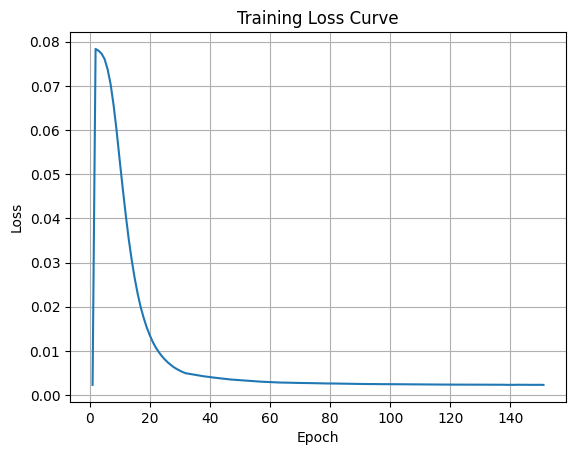

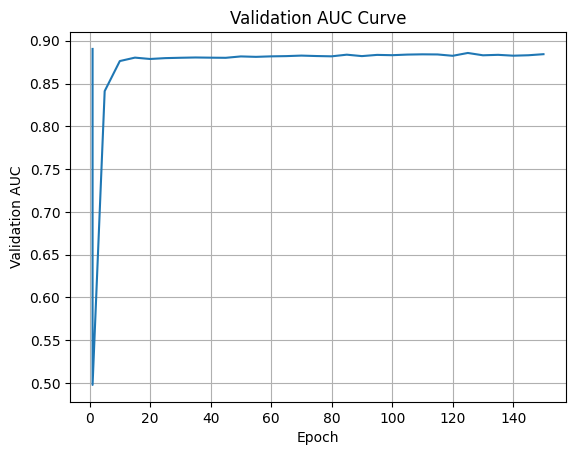

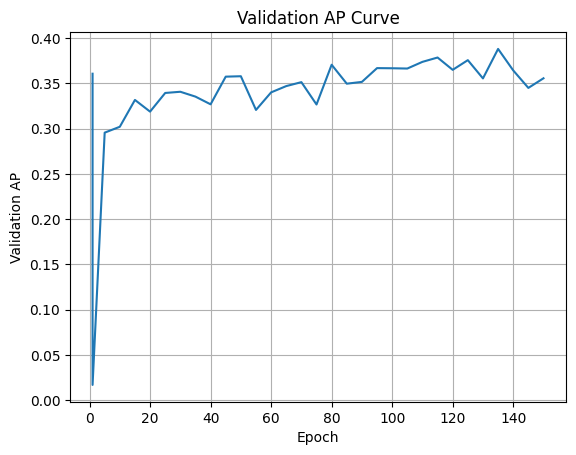

In [59]:
import matplotlib.pyplot as plt

# ---- Training Loss Curve ----
plt.figure()
plt.plot(range(1, len(train_losses)+1), train_losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Curve")
plt.grid()
plt.show()


# ---- Validation AUC Curve ----
plt.figure()
plt.plot(val_epochs, val_aucs)
plt.xlabel("Epoch")
plt.ylabel("Validation AUC")
plt.title("Validation AUC Curve")
plt.grid()
plt.show()


# ---- Validation AP Curve ----
plt.figure()
plt.plot(val_epochs, val_aps)
plt.xlabel("Epoch")
plt.ylabel("Validation AP")
plt.title("Validation AP Curve")
plt.grid()
plt.show()

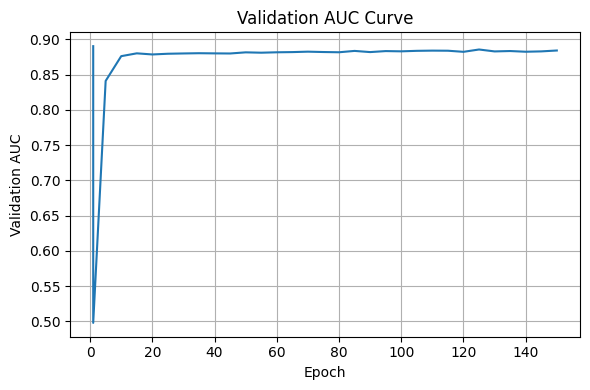

In [60]:
plt.figure(figsize=(6,4))
plt.plot(val_epochs, val_aucs)
plt.xlabel("Epoch")
plt.ylabel("Validation AUC")
plt.title("Validation AUC Curve")
plt.grid(True)
plt.tight_layout()
plt.savefig("auc_curve.png", dpi=300)
plt.show()

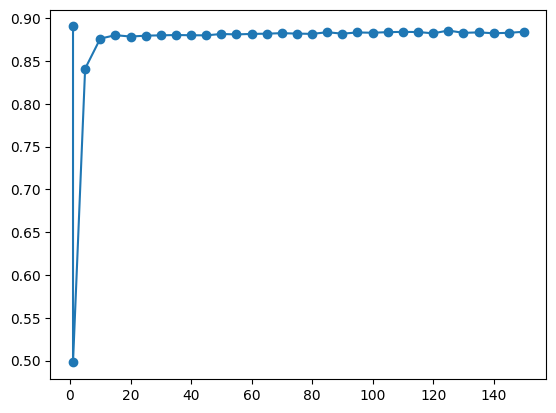

In [62]:
plt.plot(val_epochs, val_aucs, marker='o', linewidth=1.5)

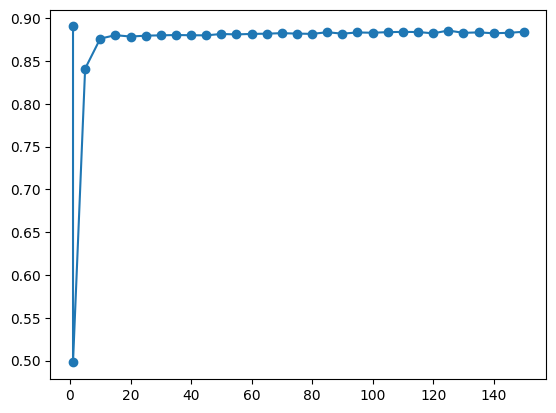

In [61]:
plt.plot(val_epochs, val_aucs, marker='o')

In [63]:
# Get all disease embeddings
model.eval()
with torch.no_grad():
    disease_embs = model.embed(torch.tensor(list(disease_idx)))

# Cluster diseases by embedding similarity
from sklearn.cluster import KMeans
from sklearn.metrics.pairwise import cosine_similarity

kmeans = KMeans(n_clusters=10, random_state=42)
clusters = kmeans.fit_predict(disease_embs.numpy())

# Find drugs effective in one cluster → predict for similar cluster

In [64]:
from sklearn.cluster import KMeans

model.eval()
with torch.no_grad():
    disease_t = torch.tensor(list(disease_idx)).to(DEVICE)
    disease_embs = model.embed(disease_t).cpu().numpy()

km = KMeans(n_clusters=12, random_state=42, n_init=10)
clusters = km.fit_predict(disease_embs)

In [65]:
print("\n=== FINAL TEST EVALUATION ===")
model.load_state_dict(torch.load(best_ckpt))
test_auc, test_ap = evaluate(test_pos[:500], "Test")


=== FINAL TEST EVALUATION ===
  [Test]  AUC: 0.9130  |  AP: 0.3825


In [66]:
from sklearn.metrics import ndcg_score

# Hits@K and NDCG@K
def hits_at_k(scores, labels, k=10):
    top_k = np.argsort(scores)[::-1][:k]
    return int(labels[top_k].sum() > 0)

# Mean Reciprocal Rank
def mrr(scores, labels):
    ranked = np.argsort(scores)[::-1]
    for i, idx in enumerate(ranked):
        if labels[idx] == 1:
            return 1.0 / (i + 1)
    return 0.0

In [68]:
# 9. Drug Repurposing Inference
# ─────────────────────────────────────────────
print("\n=== TOP DRUG REPURPOSING CANDIDATES ===")
 
# Reverse maps for readable output
idx2node  = {v: k for k, v in node2idx.items()}
node2name = dict(zip(nodes["neo4j_id"], nodes.get("name", nodes["neo4j_id"])))
 
model.eval()
disease_list_t = torch.tensor(list(disease_idx)).to(DEVICE)
 
# Pick 5 random drugs and show top-5 repurposing candidates
sample_drugs = random.sample(list(drug_idx), 5)
with torch.no_grad():
    for drug_i in sample_drugs:
        drug_t    = torch.tensor([drug_i]*len(disease_list_t)).to(DEVICE)
        scores    = torch.sigmoid(model(drug_t, disease_list_t)).cpu().numpy()
        top5_idx  = np.argsort(scores)[::-1][:5]
        orig_drug = idx2node[drug_i]
        print(f"\n  Drug {orig_drug}  →  Top disease candidates:")
        for rank, di in enumerate(top5_idx, 1):
            orig_dis = idx2node[disease_list_t[di].item()]
            sc       = scores[di]
            known    = "✓ known" if (drug_i, disease_list_t[di].item()) in pos_set else ""
            print(f"    {rank}. Disease {orig_dis}  score={sc:.4f}  {known}")
 
print("\nDone! Best model saved to:", best_ckpt)
print(f"Best Val AUC: {best_val_auc:.4f}  |  Test AUC: {test_auc:.4f}  |  Test AP: {test_ap:.4f}")
 


=== TOP DRUG REPURPOSING CANDIDATES ===

  Drug 14955  →  Top disease candidates:
    1. Disease 858  score=0.5214  
    2. Disease 1383  score=0.5143  
    3. Disease 75  score=0.5135  
    4. Disease 1739  score=0.5130  
    5. Disease 623  score=0.5127  

  Drug 736  →  Top disease candidates:
    1. Disease 737  score=0.9902  ✓ known
    2. Disease 476  score=0.9801  
    3. Disease 1312  score=0.9784  
    4. Disease 491  score=0.9660  
    5. Disease 927  score=0.9282  

  Drug 1600  →  Top disease candidates:
    1. Disease 377  score=0.9959  ✓ known
    2. Disease 1385  score=0.9944  ✓ known
    3. Disease 28  score=0.9899  
    4. Disease 828  score=0.9304  
    5. Disease 770  score=0.8903  

  Drug 1301  →  Top disease candidates:
    1. Disease 7  score=0.5264  
    2. Disease 328  score=0.5261  
    3. Disease 348  score=0.5246  
    4. Disease 785  score=0.5234  
    5. Disease 476  score=0.5227  

  Drug 139  →  Top disease candidates:
    1. Disease 140  score=0.9968  

In [38]:
def compute_metrics(model, test_edges, all_entities):
    hits_1, hits_3, hits_10 = 0, 0, 0
    mrr = 0
    total = len(test_edges)

    for (drug, _, true_disease) in test_edges:
        
        scores = []
        for disease in all_entities:
            score = model.predict(drug, disease)
            scores.append((disease, score))

        # sort descending
        scores.sort(key=lambda x: x[1], reverse=True)

        ranked = [d for d, _ in scores]

        rank = ranked.index(true_disease) + 1

        if rank <= 1:
            hits_1 += 1
        if rank <= 3:
            hits_3 += 1
        if rank <= 10:
            hits_10 += 1

        mrr += 1.0 / rank

    return {
        "Hits@1": hits_1 / total,
        "Hits@3": hits_3 / total,
        "Hits@10": hits_10 / total,
        "MRR": mrr / total
    }